# Phase 4 — Portfolio Optimisation: Example Notebook

Demonstrates the `quant_trading.optim` module using **synthetic data only** — no real tickers, API keys, or credentials.

Topics covered:
1. Synthetic data generation
2. `AssetAllocator` — mean-variance and risk parity
3. Covariance estimator comparison
4. Efficient frontier
5. `StrategyAllocator` — allocating across strategies
6. Factor model — OLS loadings, exposures, attribution
7. `portfolio_analytics` — comprehensive statistics

In [1]:
import sys
sys.path.insert(0, '../../src')  # resolve local package

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

from quant_trading.optim import (
    AssetAllocator,
    StrategyAllocator,
    OptimMethod,
    efficient_frontier,
    portfolio_analytics,
    compute_factor_loadings,
    compute_factor_exposures,
    compute_factor_attribution,
)
from quant_trading.optim.covariance import sample_covariance, ledoit_wolf, ewm_covariance

print('Imports OK')

Imports OK


## 1. Synthetic Data

We generate 5 correlated synthetic assets with known properties.

In [2]:
RNG = np.random.default_rng(0)
N_PERIODS = 756   # 3 years of daily returns
ASSETS = ['Tech', 'Finance', 'Energy', 'Health', 'Consumer']

# True expected daily returns and covariance structure
mu_daily = np.array([8e-4, 5e-4, 4e-4, 6e-4, 5e-4])
corr = np.array([
    [1.00, 0.30, 0.10, 0.20, 0.25],
    [0.30, 1.00, 0.40, 0.15, 0.30],
    [0.10, 0.40, 1.00, 0.05, 0.10],
    [0.20, 0.15, 0.05, 1.00, 0.35],
    [0.25, 0.30, 0.10, 0.35, 1.00],
])
vols_daily = np.array([0.018, 0.014, 0.020, 0.013, 0.012])
cov_daily = np.outer(vols_daily, vols_daily) * corr

raw = RNG.multivariate_normal(mu_daily, cov_daily, size=N_PERIODS)
idx = pd.date_range('2021-01-04', periods=N_PERIODS, freq='B')
returns = pd.DataFrame(raw, index=idx, columns=ASSETS)

print(f'Returns shape: {returns.shape}')
print('\nAnnualised stats:')
stats = pd.DataFrame({
    'Ann. Return (%)': returns.mean() * 252 * 100,
    'Ann. Vol (%)': returns.std() * np.sqrt(252) * 100,
}).round(2)
display(stats)

Returns shape: (756, 5)

Annualised stats:


,Ann. Return (%),Ann. Vol (%)
Tech,8.94,27.99
Finance,16.59,22.78
Energy,58.00,30.86
Health,33.79,20.59
Consumer,23.57,20.17


## 2. AssetAllocator — Mean-Variance vs Risk Parity

In [3]:
# Supply explicit ("true") annualised expected returns
mu_ann = pd.Series(mu_daily * 252, index=ASSETS)

# Mean-variance
mv_allocator = AssetAllocator(method='mean_variance', cov_estimator='ledoit_wolf')
mv_result = mv_allocator.optimise(returns, expected_returns=mu_ann)

# Risk parity
rp_allocator = AssetAllocator(method='risk_parity', cov_estimator='ledoit_wolf')
rp_result = rp_allocator.optimise(returns)

# Comparison table
comparison = pd.DataFrame({
    'MVO weight (%)': (mv_result.weights * 100).round(1),
    'Risk Parity weight (%)': (rp_result.weights * 100).round(1),
})
display(comparison)

print(f'\nMVO solver: {mv_result.optim_result.solver_used}, status: {mv_result.optim_result.status}')
print(f'MVO expected return: {mv_result.optim_result.expected_return:.2%}')
print(f'MVO expected vol:    {mv_result.optim_result.expected_vol:.2%}')
print(f'MVO Sharpe:          {mv_result.optim_result.sharpe:.2f}')

,MVO weight (%),Risk Parity weight (%)
Tech,100.0,16.5
Finance,0.0,19.4
Energy,0.0,17.3
Health,0.0,24.9
Consumer,0.0,22.0



MVO solver: OSQP, status: optimal
MVO expected return: 20.16%
MVO expected vol:    1.76%
MVO Sharpe:          11.47


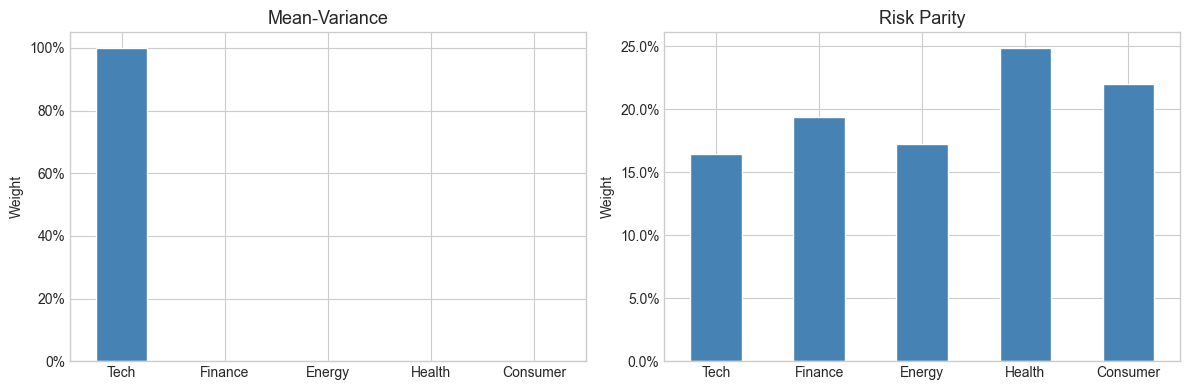

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, result, title in zip(axes, [mv_result, rp_result], ['Mean-Variance', 'Risk Parity']):
    result.weights.plot.bar(ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('Weight')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_xticklabels(result.weights.index, rotation=0)

plt.tight_layout()
plt.show()

## 3. Covariance Estimator Comparison

In [5]:
estimators = ['sample', 'ledoit_wolf', 'ewm', 'constant_correlation']
rows = []
for est in estimators:
    alloc = AssetAllocator(method='mean_variance', cov_estimator=est)
    res = alloc.optimise(returns, expected_returns=mu_ann)
    rows.append({
        'Estimator': est,
        'Status': res.optim_result.status,
        'Exp. Return (%)': f"{res.optim_result.expected_return:.2%}",
        'Exp. Vol (%)':    f"{res.optim_result.expected_vol:.2%}",
        'Sharpe':          f"{res.optim_result.sharpe:.2f}",
    })

display(pd.DataFrame(rows))

,Estimator,Status,Exp. Return (%),Exp. Vol (%),Sharpe
0,sample,optimal,20.16%,1.76%,11.43
1,ledoit_wolf,optimal,20.16%,1.76%,11.47
2,ewm,optimal,20.16%,1.71%,11.76
3,constant_correlation,optimal,20.16%,1.76%,11.43


## 4. Efficient Frontier

Polishing not needed - no active set detected at optimal point
Frontier points: 60


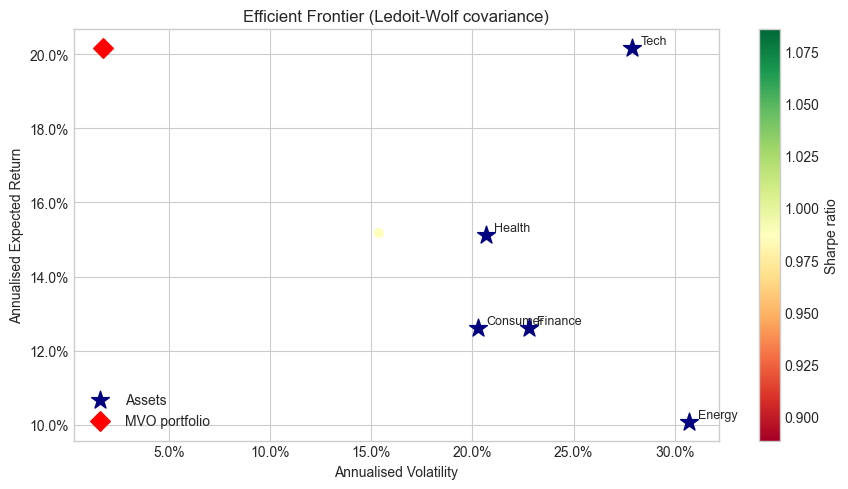

In [6]:
from quant_trading.optim.covariance import ledoit_wolf as lw
cov_ann = lw(returns) * 252

frontier = efficient_frontier(mu_ann.values, cov_ann, n_points=60)
print(f'Frontier points: {len(frontier)}')

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(frontier['vol'], frontier['ret'], c=frontier['sharpe'],
                cmap='RdYlGn', s=30, zorder=3)
plt.colorbar(sc, ax=ax, label='Sharpe ratio')

# Plot individual assets
asset_vols = np.sqrt(np.diag(cov_ann))
ax.scatter(asset_vols, mu_ann.values, marker='*', s=180, color='navy', zorder=5, label='Assets')
for i, name in enumerate(ASSETS):
    ax.annotate(name, (asset_vols[i], mu_ann.values[i]), textcoords='offset points',
                xytext=(6, 3), fontsize=9)

# Plot MVO portfolio
ax.scatter(mv_result.optim_result.expected_vol, mv_result.optim_result.expected_return,
           marker='D', s=100, color='red', zorder=5, label='MVO portfolio')

ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xlabel('Annualised Volatility')
ax.set_ylabel('Annualised Expected Return')
ax.set_title('Efficient Frontier (Ledoit-Wolf covariance)')
ax.legend()
plt.tight_layout()
plt.show()

## 5. StrategyAllocator — Allocating Across Strategies

In [7]:
# Simulate 3 strategy return streams (daily)
STRATEGIES = ['momentum', 'value', 'trend']
strat_mu = np.array([7e-4, 4e-4, 5e-4])
strat_cov = np.array([[1.5e-4, -0.2e-4, 0.1e-4],
                       [-0.2e-4, 1.0e-4, 0.0e-4],
                       [0.1e-4, 0.0e-4, 0.8e-4]])
strat_raw = RNG.multivariate_normal(strat_mu, strat_cov, size=N_PERIODS)
strategy_returns = pd.DataFrame(strat_raw, index=idx, columns=STRATEGIES)

# Risk parity allocation
strat_allocator = StrategyAllocator(method='risk_parity', cov_estimator='ledoit_wolf')
strat_result = strat_allocator.optimise(strategy_returns)
print('Risk parity strategy weights:')
print((strat_result.weights * 100).round(1).to_string())

# Mean-variance with explicit expected returns (private repo would supply these)
explicit_mu = pd.Series({'momentum': 0.18, 'value': 0.10, 'trend': 0.13})
strat_mv = StrategyAllocator(method='mean_variance')
strat_mv_result = strat_mv.optimise(strategy_returns, expected_returns=explicit_mu)
print('\nMean-variance strategy weights (explicit expected returns):')
print((strat_mv_result.weights * 100).round(1).to_string())

Risk parity strategy weights:
momentum    28.2
value       35.8
trend       36.0

Mean-variance strategy weights (explicit expected returns):
momentum    100.0
value         0.0
trend         0.0


## 6. Factor Model — OLS Loadings, Exposures, Attribution

We simulate two synthetic factors (analogous to FF Mkt-RF and SMB) and
compute factor loadings via OLS.

In the **private repository**, you would replace `factor_rets` with data from
`FamaFrenchConnector.fetch_factor_returns()` and supply your strategy returns.

In [8]:
# Simulate two factor return streams
factor_rets = pd.DataFrame(
    RNG.multivariate_normal([3e-4, 1e-4], [[1.2e-4, 2e-5], [2e-5, 8e-5]], size=N_PERIODS),
    index=idx,
    columns=['Mkt-RF', 'SMB'],
)

# Compute OLS factor loadings
factor_model = compute_factor_loadings(returns, factor_rets)

print('Factor loadings (betas):')
display(factor_model.loadings.round(3))
print('\nR²:')
display(factor_model.r_squared.round(3))

Factor loadings (betas):


,Mkt-RF,SMB
Tech,-0.035,0.028
Finance,0.059,0.012
Energy,-0.017,0.129
Health,-0.104,0.121
Consumer,-0.017,0.009



R²:


Tech        0.001
Finance     0.002
Energy      0.004
Health      0.012
Consumer    0.000
Name: r_squared, dtype: float64

In [9]:
# Portfolio factor exposures
exposures = compute_factor_exposures(mv_result.weights, factor_model)
print('MVO portfolio factor exposures:')
display(exposures.round(3).to_frame('exposure'))

# Variance attribution
attr = compute_factor_attribution(mv_result.weights, factor_model)
print(f"\nVariance attribution:")
print(f"  Systematic:    {attr['systematic_pct']:.1f}%")
print(f"  Idiosyncratic: {attr['idiosyncratic_pct']:.1f}%")

MVO portfolio factor exposures:


,exposure
Mkt-RF,-0.035
SMB,0.028



Variance attribution:
  Systematic:    0.1%
  Idiosyncratic: 99.9%


## 7. Portfolio Analytics

In [10]:
analytics = portfolio_analytics(
    weights=mv_result.weights,
    returns=returns,
    factor_model=factor_model,
)

# Display key stats
stats_rows = [
    ('Annualised Return', f"{analytics['annualised_return']:.2%}"),
    ('Annualised Vol',    f"{analytics['annualised_vol']:.2%}"),
    ('Sharpe Ratio',      f"{analytics['sharpe']:.2f}"),
    ('Max Drawdown',      f"{analytics['max_drawdown']:.2%}"),
    ('Calmar Ratio',      f"{analytics['calmar_ratio']:.2f}"),
    ('Sortino Ratio',     f"{analytics['sortino_ratio']:.2f}"),
    ('Skewness',          f"{analytics['skewness']:.3f}"),
    ('Excess Kurtosis',   f"{analytics['kurtosis']:.3f}"),
    ('1-Day 95% VaR',     f"{analytics['var_95']:.2%}"),
    ('1-Day 95% CVaR',    f"{analytics['cvar_95']:.2%}"),
    ('Hit Rate',          f"{analytics['hit_rate']:.1%}"),
]
display(pd.DataFrame(stats_rows, columns=['Metric', 'Value']))

,Metric,Value
0,Annualised Return,8.94%
1,Annualised Vol,27.99%
2,Sharpe Ratio,0.32
3,Max Drawdown,-23.25%
4,Calmar Ratio,0.38
5,Sortino Ratio,0.56
6,Skewness,0.060
7,Excess Kurtosis,-0.285
8,1-Day 95% VaR,-2.79%
9,1-Day 95% CVaR,-3.46%


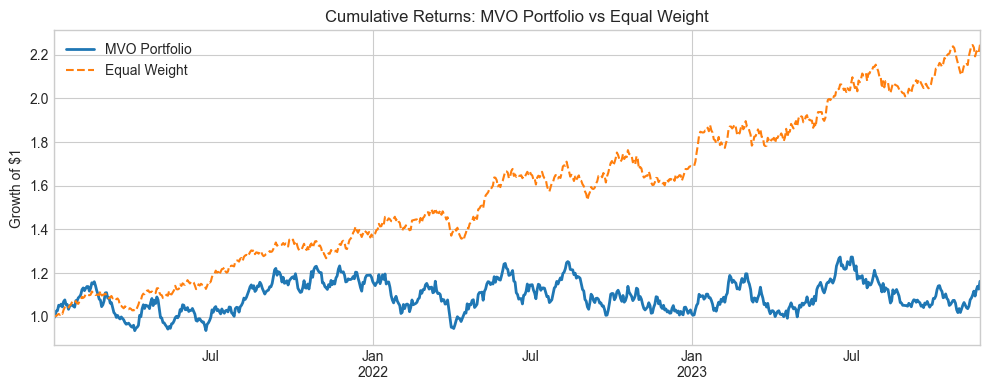

In [11]:
# Cumulative return plot
port_ret = returns[mv_result.weights.index].dot(mv_result.weights)
eq_ret   = returns.mean(axis=1)  # equal weight benchmark

fig, ax = plt.subplots(figsize=(10, 4))
(1 + port_ret).cumprod().plot(ax=ax, label='MVO Portfolio', linewidth=2)
(1 + eq_ret).cumprod().plot(ax=ax, label='Equal Weight', linewidth=1.5, linestyle='--')
ax.set_title('Cumulative Returns: MVO Portfolio vs Equal Weight')
ax.set_ylabel('Growth of $1')
ax.legend()
plt.tight_layout()
plt.show()